# CAN BE IGNORED FOR THE TIME BEING

In [35]:
import glob
import cv2

import h5py
import numpy as np
import matplotlib.pyplot as plt
from pymatreader import read_mat

import torch
from PIL import Image
from tqdm import tqdm
import os

%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 531 µs (started: 2024-11-27 10:36:53 -05:00)


In [37]:
filename = "../data/nyu.mat"

# Open the .mat file
with h5py.File(filename , "r") as mat_file:
    # Inspect the keys
    print("Keys in the file:", list(mat_file.keys()))

    # Access a dataset
    images = mat_file['images']  # Replace 'images' with the actual key in your file
    instances = mat_file['instances']  # Replace with actual key
    labels = mat_file['labels']
    names = mat_file['names']

    # Convert datasets to NumPy arrays
    images = images[()]  # If images is a dataset, this retrieves it as a NumPy array
    instances = instances[()]
    labels = labels[()]
    names = names[()]

Keys in the file: ['#refs#', '#subsystem#', 'accelData', 'depths', 'images', 'instances', 'labels', 'names', 'namesToIds', 'rawDepthFilenames', 'rawDepths', 'rawRgbFilenames', 'sceneTypes', 'scenes']
time: 14.4 s (started: 2024-11-27 10:39:32 -05:00)


In [53]:
data = read_mat(filename, variable_names=['names'])
idsToNames = {}
namesToIds = {name:(n+1) for n, name in enumerate(data['names'])}
for key, value in namesToIds.items():
    idsToNames[value] = key

time: 83.4 ms (started: 2024-11-27 10:58:27 -05:00)


In [3]:
print(instances.shape)

(1449, 640, 480)
time: 186 µs (started: 2024-11-27 10:12:07 -05:00)


In [8]:
print(labels.shape)

(1449, 640, 480)
time: 296 µs (started: 2024-11-27 10:15:59 -05:00)


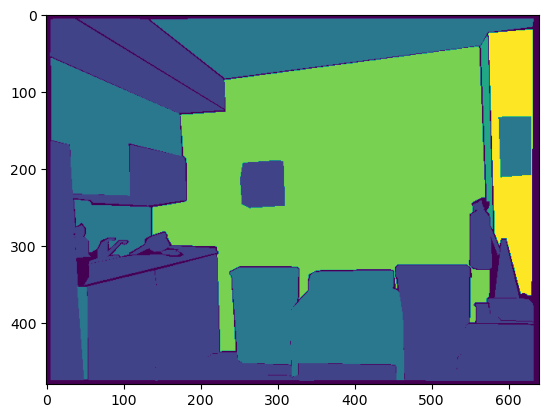

time: 85.6 ms (started: 2024-11-27 10:12:52 -05:00)


In [6]:
plt.imshow(np.rot90(instances[0], k=-1))

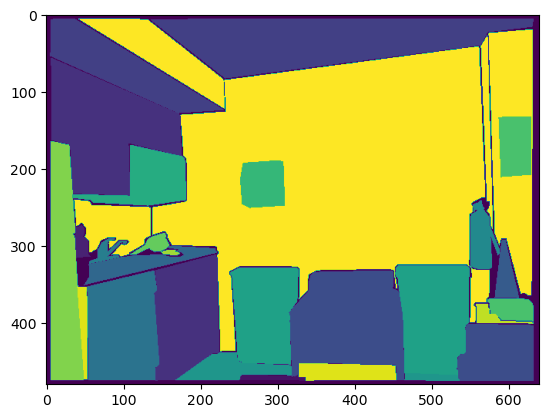

time: 87.6 ms (started: 2024-11-27 10:16:22 -05:00)


In [9]:
plt.imshow(np.rot90(labels[0], k=-1))

### Decoding namesToIds

In [23]:
print(type(namesToIds))

<class 'numpy.ndarray'>
time: 240 µs (started: 2024-11-27 10:27:40 -05:00)


In [24]:
print(namesToIds.shape)

(1, 6)
time: 232 µs (started: 2024-11-27 10:27:49 -05:00)


In [28]:
print(namesToIds)

[[3707764736          2          1          1          1          1]]
time: 504 µs (started: 2024-11-27 10:29:12 -05:00)


In [32]:
print(len(names[0]))

894
time: 196 µs (started: 2024-11-27 10:32:26 -05:00)


In [45]:
target_categories = ['bathtub', 'bed', 'bookshelf', 'box', 'chair', 'counter', 'desk', 'door', 'dresser', 'garbage-bin', 'lamp', 'monitor', 'night-stand', 'pillow', 'sink', 'sofa', 'table', 'television', 'toilet']
print(f"Total categories: {len(target_categories)}")

for key, value in namesToIds.items():
    if key in target_categories:
        print(f"{value}: {key}")

Total categories: 19
5: chair
7: counter
19: table
24: sink
26: box
28: door
36: desk
49: monitor
83: sofa
88: bookshelf
119: pillow
124: toilet
136: bathtub
144: lamp
157: bed
169: dresser
172: television
time: 2.31 ms (started: 2024-11-27 10:50:08 -05:00)


### Trying to get binary mask for each object in the images

In [66]:
image_idx = 1
instance_map = np.fliplr(np.rot90(instances[image_idx], k=-1))  

# Get unique instance IDs (ignoring background 0)
instance_ids = np.unique(instance_map)
instance_ids = instance_ids[instance_ids != 0]  # Remove background ID

# Generate binary masks for each instance
binary_masks = [(instance_map == instance_id) for instance_id in instance_ids]

time: 2.9 ms (started: 2024-11-27 11:42:11 -05:00)


In [65]:
print(instance_ids)

[ 1  2  3  4  5  6  7  8  9 10 11]
time: 355 µs (started: 2024-11-27 11:41:59 -05:00)


In [14]:
print(len(binary_masks))

5
time: 190 µs (started: 2024-11-27 10:24:08 -05:00)


book


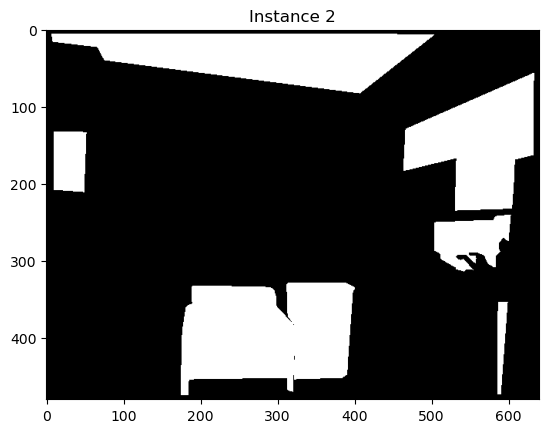

time: 80.1 ms (started: 2024-11-27 11:00:20 -05:00)


In [61]:
idx = 1

print(idsToNames[idx])
plt.imshow(binary_masks[idx], cmap='gray')
plt.title(f'Instance {instance_ids[idx]}')
plt.show()

In [67]:
def get_instance_masks(imgObjectLabels, imgInstances):
    """
    Returns a series of masks for each object instance in the given scene.

    Args:
        imgObjectLabels (np.ndarray): HxW label map. 0 indicates a missing label.
        imgInstances (np.ndarray): HxW instance map.

    Returns:
        instanceMasks (np.ndarray): Binary masks of size HxWxN where N is the number 
                                     of total objects in the scene.
        instanceLabels (np.ndarray): Nx1 array of class labels for each instance mask.
    """
    H, W = imgObjectLabels.shape

    # Combine object labels and instance IDs into unique pairs
    pairs = np.unique(np.stack((imgObjectLabels.ravel(), imgInstances.ravel()), axis=1), axis=0)
    
    # Remove rows where both label and instance ID are 0 (background)
    pairs = pairs[np.sum(pairs, axis=1) != 0]

    # Number of unique instances
    N = pairs.shape[0]

    # Initialize instance masks and labels
    instanceMasks = np.zeros((H, W, N), dtype=bool)
    instanceLabels = np.zeros(N, dtype=int)

    # Generate binary masks for each instance
    for ii in range(N):
        label, instance_id = pairs[ii]
        instanceMasks[:, :, ii] = (imgObjectLabels == label) & (imgInstances == instance_id)
        instanceLabels[ii] = label

    return instanceMasks, instanceLabels


time: 738 µs (started: 2024-11-27 11:46:25 -05:00)
